mass: 12.861412657852622 kg
Segment Times: [ 0  2 17 67 77 82 92]
[0.         0.04081633 0.08163265 0.12244898 0.16326531 0.20408163
 0.24489796 0.28571429 0.32653061 0.36734694 0.40816327 0.44897959
 0.48979592 0.53061224 0.57142857 0.6122449  0.65306122 0.69387755
 0.73469388 0.7755102  0.81632653 0.85714286 0.89795918 0.93877551
 0.97959184 1.02040816 1.06122449 1.10204082 1.14285714 1.18367347
 1.2244898  1.26530612 1.30612245 1.34693878 1.3877551  1.42857143
 1.46938776 1.51020408 1.55102041 1.59183673 1.63265306 1.67346939
 1.71428571 1.75510204 1.79591837 1.83673469 1.87755102 1.91836735
 1.95918367 2.        ]
[ 2.          2.30612245  2.6122449   2.91836735  3.2244898   3.53061224
  3.83673469  4.14285714  4.44897959  4.75510204  5.06122449  5.36734694
  5.67346939  5.97959184  6.28571429  6.59183673  6.89795918  7.20408163
  7.51020408  7.81632653  8.12244898  8.42857143  8.73469388  9.04081633
  9.34693878  9.65306122  9.95918367 10.26530612 10.57142857 10.87755102
 11.18367

Text(0.5, 0, 's')

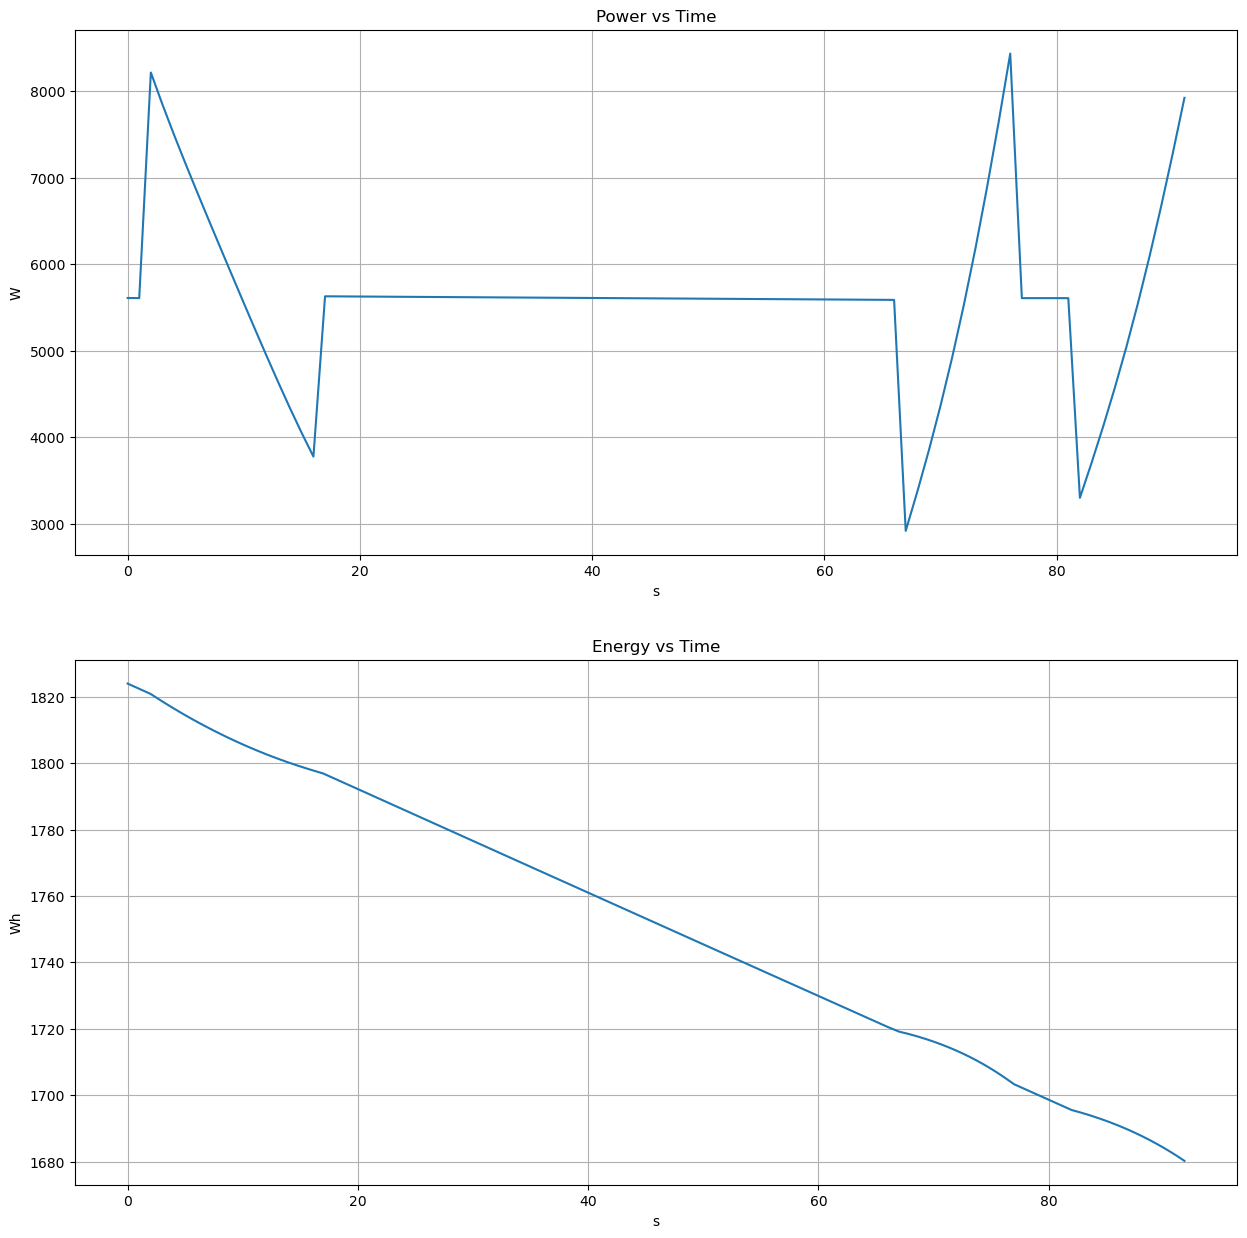

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces

drag_coeff = 0.256

# Mass Analysis Setup
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))
arm_beam = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")
d1 = DroneGeometry("drone_test", 1000, 660, 8, arm_beam, strut_beam, [battery_1, battery_2])
d1_mass = DroneMass(d1)

# Mass Analysis results
print("mass:", d1_mass.total_mass * 1000, "kg")
total_mass = d1_mass.total_mass + (35 * 10 ** -3)
surface_area = d1.projected_surface_area

# Mission Profile generation
m1 = MissionProfile("m1", 1, 0, 0)
m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,0)
m1.add_segment("cruise",50,2000000,110000,300,0)
m1.add_segment("descent",10,2200000,50000,0,0)
m1.add_segment("loiter",5,2200000,50000,0,0)
m1.add_segment("land",10,2400000,0,0,0)

# Drone Force Analysis
d1_forces = DroneForces(total_mass, surface_area, drag_coeff, m1)

# Drone
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)
drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)

print("Segment Times:", m1.t_values)

# Creating Power Plot Data
power_list = np.zeros(m1.t_values[-1])
time_list = np.arange(m1.t_values[-1])
for t in time_list:
    power_list[t] = drone_power.power_at_time(t)

time_ec, energy_consumption = drone_power.energy_consumption(50, m1.t_values)

print("Timesteps:", time_ec)

# Plotting
fig, axs = plt.subplots(2,1)

fig.set_figheight(15)
fig.set_figwidth(15)


axs[0].set_title("Power vs Time")
axs[0].plot(time_list, power_list / 1000)
axs[0].grid()
axs[0].set_ylabel("W")
axs[0].set_xlabel("s")


axs[1].set_title("Energy vs Time")
axs[1].plot(time_ec, energy_consumption / 3600000)
axs[1].grid()
axs[1].set_ylabel("Wh")
axs[1].set_xlabel("s")

In [17]:
print(0.5 * (1820/((1820-1701)/83)) / 60 )

10.578431372549018
